# Combined Results Figure

This notebook generates a comprehensive figure combining three types of analysis:
- **Pareto Analysis**: Shows the trade-off between accuracy and calibration error
- **Time Series**: Displays metric evolution across continual learning tasks  
- **Calibration**: Visualizes calibration error curves across confidence bins

The final output is saved as both PNG and PDF formats for publication.

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
from common import (
    DATASET_TO_LABEL,
    METHOD_TO_LABEL,
    METRIC_TO_LABEL,
    OFFLINE,
    PLOT_METHODS,
    get_color,
    get_label,
    get_linestyle,
    get_marker,
)
from matplotlib import pyplot as plt
from matplotlib.axes import Axes

PARETO_SCATTER_ALPHA = 0.7
GRID_STYLE = dict(color="lightgray", linewidth=0.5)

# PARETO_X_LABEL = ""
# PARETO_Y_LABEL = "Time (s) $\downarrow$"

# TIME_SERIES_X_LABEL = "Tasks Seen"
# TIME_SERIES_Y_LABEL = "Accuracy (%)"

# CALIBRATION_X_LABEL = "Confidence Bin (%)"
# CALIBRATION_Y_LABEL = "Calibration Error (%)"

## Pareto

In [9]:
def pareto_front(df: pd.DataFrame, y_key: str, x_key: str) -> pd.DataFrame:
    """Find the Pareto front for given x and y metrics.

    Args:
        df: DataFrame with data points
        y_key: Column name for y-axis metric (lower is better)
        x_key: Column name for x-axis metric (higher is better)

    Returns:
        DataFrame containing only Pareto-optimal points
    """
    df = df.sort_values(by=[y_key, x_key], ascending=[True, False])
    pareto_points = []
    max_acc = -1.0
    for _, row in df.iterrows():
        if row[x_key] > max_acc:
            pareto_points.append(row)
            max_acc = row[x_key]
    return pd.DataFrame(pareto_points)


def plot_pareto(df, axes):
    """Plot Pareto fronts for accuracy vs ECE across datasets."""
    x_key = "accuracy_seen_avg"
    y_key = "ece_seen_avg"
    x_label = METRIC_TO_LABEL.get(x_key, x_key)
    y_label = METRIC_TO_LABEL.get(y_key, y_key)

    df_fair = df[~df["method"].isin(OFFLINE)]

    dataset_df = {
        dataset: df_fair[df_fair["dataset"] == dataset][[y_key, x_key, "method"]]
        for dataset in DATASET_TO_LABEL.keys()
    }

    # Convert to percentage
    for df in dataset_df.values():
        df[y_key] = df[y_key] * 100
        df[x_key] = df[x_key] * 100

    for (dataset, dataset_label), ax in zip(DATASET_TO_LABEL.items(), axes):
        df = dataset_df[dataset]
        # Filter to only methods in METHOD_TO_LABEL
        df = df[df["method"].isin(METHOD_TO_LABEL.keys())]
        # means = df.groupby("method", sort=True).mean()

        ax.set_zorder(3)
        ax.grid(True, **GRID_STYLE)

        # Plot Pareto front
        # pf = pareto_front(means, y_key, x_key)
        # ax.plot(pf[x_key], pf[y_key], color="black", linestyle="-", zorder=1)

        # Scatter plot for individual runs
        for method in PLOT_METHODS:
            mask = df["method"] == method
            ax.scatter(
                df[mask][x_key],
                df[mask][y_key],
                color=get_color(method),
                marker=get_marker(method),
                label=get_label(method),
                alpha=PARETO_SCATTER_ALPHA,
            )

        ax.set_xlabel("")
        ax.set_ylabel("")

        # ax.yaxis.set_major_locator(plt.MultipleLocator(2))
        # ax.yaxis.set_minor_locator(plt.MultipleLocator(1))

        # ax.xaxis.set_major_locator(plt.MultipleLocator(5))
        # ax.xaxis.set_minor_locator(plt.MultipleLocator(1))

        ax.set_title(dataset_label)

    axes[0].set_ylabel(y_label)
    axes[1].set_xlabel(x_label)

## Time Series

In [10]:
def plot_dataset(df: pd.DataFrame, metric: str, ax: Axes, factor: float = 1.0) -> None:
    """Plot time series data for a single dataset."""
    for name in PLOT_METHODS:
        method_df = df[df["method"] == name]

        data = method_df.groupby("task").aggregate({metric: ["mean", "std"]})
        mean = data[metric]["mean"].to_numpy() * factor
        std = data[metric]["std"].to_numpy() * factor
        task = data.index.to_numpy() + 1

        color = get_color(name)
        ax.plot(
            task,
            mean,
            label=get_label(name),
            color=color,
            linestyle=get_linestyle(name),
        )
        ax.fill_between(task, mean - std, mean + std, alpha=0.2, color=color)


def plot_time_series(df: pd.DataFrame, metric: str, axes):
    """Plot time series for each dataset showing metric evolution across tasks."""
    for dataset, ax in zip(DATASET_TO_LABEL.keys(), axes):
        dataset_df = df[df["dataset"] == dataset]

        plot_dataset(dataset_df, metric, ax, factor=100.0)

        # Add tick for each task
        ax.xaxis.set_minor_locator(plt.MultipleLocator(1))
        ax.xaxis.set_major_locator(plt.MultipleLocator(2))

        # Add grid
        ax.grid(True, **GRID_STYLE)

    axes[0].set_ylabel(METRIC_TO_LABEL.get(metric, metric))
    axes[1].set_xlabel("Task")

## Calibration

In [11]:
def dataset_calibration(df: pd.DataFrame, ax: Axes):
    """Plot calibration error for a single dataset."""
    for method in PLOT_METHODS:
        calibration = (
            df[df["method"] == method]
            .groupby("bin")
            .aggregate(
                {
                    "bin_probability": ["mean", "std"],
                    "bin_frequency": ["mean", "std"],
                    "bin_weight": ["mean", "std"],
                }
            )
        )

        bp = calibration["bin_probability"] * 100
        bf = calibration["bin_frequency"] * 100
        x = np.linspace(0, 1, len(bp)) * 100
        error = bf["mean"] - bp["mean"]
        error_std = np.sqrt(bp["std"] ** 2 + bf["std"] ** 2)

        color = get_color(method)
        ax.plot(
            x,
            error,
            label=get_label(method),
            color=color,
            linestyle=get_linestyle(method),
        )
        ax.fill_between(
            x,
            error - error_std,
            error + error_std,
            alpha=0.1,
            color=color,
            linewidth=0,
        )

    # ax.set_ylim(-30, 30)
    ax.axhline(0, color="black", linestyle="-", linewidth=1)


def plot_calibration(df: pd.DataFrame, axes):
    """Plot calibration error curves for each dataset."""
    y_label = (
        "Calibration Error\n"
        + r"$\operatorname{acc}\left(B_m\right) - \operatorname{conf}\left(B_m\right)$"
    )
    for dataset, ax in zip(DATASET_TO_LABEL.keys(), axes):
        dataset_df = df[df["dataset"] == dataset]

        dataset_calibration(dataset_df, ax)

        # Add grid
        ax.grid(True, **GRID_STYLE)

    axes[0].set_ylabel(y_label, fontsize=8)
    axes[1].set_xlabel("Bin $B_m$")

In [12]:
def plot_legend(ax):
    """Create a legend for all plotting methods."""
    handles = []
    labels = []
    for method, label in METHOD_TO_LABEL.items():
        if method in PLOT_METHODS:
            handles.append(
                plt.Line2D(
                    [],
                    [],
                    color=get_color(method),
                    marker=get_marker(method),
                    linestyle=get_linestyle(method),
                )
            )
            labels.append(label)
    ax.legend(
        handles,
        labels,
        ncol=len(handles) // 2 + 1,
        fontsize=8,
        frameon=False,
        loc="center",
    )
    ax.axis("off")

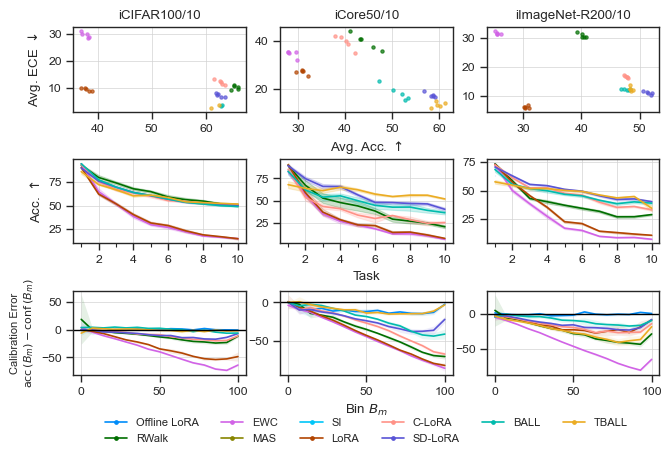

In [13]:
# Set up figure dimensions and style
width = (496.85 / 72.27) * 1.1
ratio = 2 ** (1 / 2)
sns.set_theme("paper", style="ticks")

# Create subplot grid
fig, cells = plt.subplots(
    4,
    3,
    figsize=(width, width / ratio),
    height_ratios=[1, 1, 1, 0.2],
)
fig.subplots_adjust(hspace=0.7)
gs = cells[0, 0].get_gridspec()

# Combine the bottom row of cells into a single cell for the legend
for ax in cells[3, :]:
    ax.remove()
legend_ax = fig.add_subplot(gs[3, :])

summary_df = pd.read_parquet("dataframe/summary.parquet")
time_series_df = pd.read_parquet("dataframe/time_series.parquet")
calibration_df = pd.read_parquet("dataframe/calibration.parquet")

# Generate plots
plot_pareto(summary_df, cells[0])
plot_time_series(time_series_df, "accuracy_seen", cells[1])
plot_calibration(calibration_df, cells[2])
plot_legend(legend_ax)

# Save figures
fig.savefig("plots/combined_figure.png", dpi=300, bbox_inches="tight")
fig.savefig("plots/results.pdf", dpi=300, bbox_inches="tight")